In [1]:
import pandas as pd
import numpy as np
from joblib import load
from preprocessor import *
from Preprocessor_LLM import *
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from transformers import pipeline
#import torch
import re
import sys
import os
from openai import OpenAI


PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
# PROMPT A MODIFIER ICI


PROMPT_CONFIG = {
    # ========== STRATÉGIE GLOBALE ==========
    "objectif": "Sélectionner les cas les plus utiles pour améliorer la détection de fraude",
    
    # ========== CE QUE LE LLM DOIT PRIVILÉGIER ==========
    "priorites": [
        "Chercher des profils très différents les uns des autres",
        "Inclure des cas suspects avec des combinaisons inhabituelles",
        "Couvrir tout le spectre de probabilités (pas seulement le milieu)",
        "Ajouter quelques cas extrêmes et atypiques"
    ],
    
    # ========== CE QUE LE LLM DOIT ÉVITER ==========
    "a_eviter": [
        "Sélectionner 50 profils similaires",
        "Se concentrer uniquement sur les cas moyens",
        "Ignorer les cas rares ou extrêmes"
    ],
    
    # ========== EXEMPLES DE PATTERNS À DÉTECTER ==========
    "patterns_interessants": [
        "Jeune conducteur + véhicule cher",
        "Pas de témoin + pas de rapport police",
        "Délai très court ou très long avant déclaration",
        "Changement d'adresse récent"
    ],
    
    # ========== PARAMÈTRES NUMÉRIQUES ==========
    "n_preselect": 500,  # Combien présélectionner par uncertainty sampling
    "n_select": 50,      # Combien sélectionner au final
}

print("✓ Configuration stratégie LLM chargée")
print(f"  Objectif: {PROMPT_CONFIG['objectif']}")
print(f"  {len(PROMPT_CONFIG['priorites'])} priorités définies")
print(f"  Présélection: {PROMPT_CONFIG['n_preselect']} → Sélection: {PROMPT_CONFIG['n_select']}")

✓ Configuration stratégie LLM chargée
  Objectif: Sélectionner les cas les plus utiles pour améliorer la détection de fraude
  4 priorités définies
  Présélection: 500 → Sélection: 50


In [3]:
data = pd.read_csv('/home/onyxia/PROJET_STATAPP/Data/Cleans/Data_for_active_learning.csv')

X = data.drop(columns=['FraudFound_P'])
y = data['FraudFound_P']

print(X.head())
print(y.head())


   Unnamed: 0    Make AccidentArea     Sex MaritalStatus  Age          Fault  \
0           0   Honda        Urban  Female        Single   21  Policy Holder   
1           1   Honda        Urban    Male        Single   34  Policy Holder   
2           2   Honda        Urban    Male       Married   47  Policy Holder   
3           3  Toyota        Rural    Male       Married   65    Third Party   
4           4   Honda        Urban  Female        Single   27    Third Party   

          PolicyType     VehiclePrice  Deductible  ...  Days_Policy_Accident  \
0  Sport - Liability  more than 69000         300  ...          more than 30   
1  Sport - Collision  more than 69000         400  ...          more than 30   
2  Sport - Collision  more than 69000         400  ...          more than 30   
3  Sedan - Liability   20000 to 29000         400  ...          more than 30   
4  Sport - Collision  more than 69000         400  ...          more than 30   

  PastNumberOfClaims AgeOfVehicle Poli

In [4]:
preprocessor = load("preprocessor.joblib")
print("✓ Preprocessor numérique chargé")

preprocessor_llm = PreprocessLLM(
    label_cols=label_cols,
    freq_cols=freq_cols,
    ordinal_cols=ordinal_cols,
    binary_cols=binary_cols,
    scale_cols=scale_cols
)

all_cols = binary_cols + label_cols + freq_cols + ordinal_cols + scale_cols
X_preprocessed = preprocessor.fit_transform(X)
X_preprocessed = pd.DataFrame(X_preprocessed, columns=all_cols)

X_raw = X.copy()

print(f"  Données numériques: {X_preprocessed.shape}")
print(f"  Données brutes (pour LLM): {X_raw.shape}")

exemple_text = preprocessor_llm.transform(X_raw.head(1))
print("\n Exemple preprocessing LLM:")
print(exemple_text[0]['text'])

✓ Preprocessor numérique chargé
  Données numériques: (15419, 20)
  Données brutes (pour LLM): (15419, 21)

 Exemple preprocessing LLM:
Âge : 21 ans
Délai avant déclaration : 1 semaines
Sexe : Female
Zone de l'accident : Urban
Responsabilité : Policy Holder
Rapport de police : No
Présence de témoins : No
Type d'agent : External
VehiclePrice : more than 69000
Days_Policy_Accident : more than 30
PastNumberOfClaims : none
AgeOfVehicle : 3 years
NumberOfSuppliments : none
AddressChange_Claim : 1 year
NumberOfCars : 3 to 4
DriverRating : 1
Deductible : 300
PolicyType : Sport - Liability
Make : Honda
MaritalStatus : Single


Le preprocessor LLM sert à convertir en données textuelles les individus, de sorte que le LLM traite la base de données choisie.

In [5]:
# Split des données

# 20% pour le test
X_pool_full, X_test, y_pool_full, y_test = train_test_split(
    X_preprocessed, y, test_size=0.2, stratify=y, random_state=42
)

# De même pour les raw
X_raw_pool_full, X_raw_test, _, _ = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

# 2% d'observations initiales pour le seed
X_init, X_pool, y_init, y_pool = train_test_split(
    X_pool_full, y_pool_full, train_size=0.02, stratify=y_pool_full, random_state=42
)

# De même pour les raw
X_raw_init, X_raw_pool, _, _ = train_test_split(
    X_raw_pool_full, y_pool_full, train_size=0.02, stratify=y_pool_full, random_state=42
)

# Données pour uncertainty sampling
X_init_US = X_init.copy()
X_pool_US = X_pool.copy()
y_init_US = y_init.copy()
y_pool_US = y_pool.copy()

# Données pour LLM sampling
X_init_LLM = X_init.copy()
X_pool_LLM = X_pool.copy()
X_raw_pool_LLM = X_raw_pool.copy()
y_init_LLM = y_init.copy()
y_pool_LLM = y_pool.copy()

print(f"  Test set: {len(X_test)} observations")
print(f"  Pool initial: {len(X_pool)} observations")
print(f"  Seed initial: {len(X_init)} observations ({len(X_init)/len(X_pool_full)*100:.1f}%)")

  Test set: 3084 observations
  Pool initial: 12089 observations
  Seed initial: 246 observations (2.0%)


In [6]:
# Initialisation des modèles et du SMOTE (par rapport à l'AL, ajout du model_LLM)

model = LGBMClassifier(
    learning_rate=0.05,
    max_depth=10,
    n_estimators=300,
    random_state=42
)

model_US = LGBMClassifier(
    learning_rate=0.05,
    max_depth=10,
    n_estimators=300,
    random_state=42
)

model_LLM = LGBMClassifier(
    learning_rate=0.05,
    max_depth=10,
    n_estimators=300,
    random_state=42
)

# SMOTE
smote = SMOTE(sampling_strategy=0.25, random_state=42)

In [7]:
# ===========================
# FONCTIONS UTILITAIRES
# ===========================
def create_summary_for_llm(text_samples, n_examples=3):
    """Crée un résumé lisible des échantillons pour le LLM"""
    summary = f"Vous avez {len(text_samples)} échantillons présélectionnés.\n\n"
    summary += f"Exemples de {min(n_examples, len(text_samples))} premiers échantillons:\n\n"
    for i, sample in enumerate(text_samples[:n_examples]):
        summary += f"--- Échantillon {i} ---\n{sample['text']}\n\n"
    return summary

def create_llm_prompt(text_samples, n_select=50):
    """Crée le prompt pour le LLM"""
    summary = create_summary_for_llm(text_samples)
    
    prompt = f"""Tu es un expert en apprentissage actif pour la détection de fraude à l'assurance.
Tu dois sélectionner les {n_select} échantillons les plus informatifs parmi {len(text_samples)} candidats présélectionnés.

Critères de sélection:
1. Maximiser l'incertitude (cas ambigus, proches de la frontière de décision)
2. Assurer la diversité des profils (âges, types de véhicules, circonstances variées)
3. Prioriser les patterns inhabituels qui pourraient révéler des fraudes

{summary}

Basé sur ces principes, fournis UNIQUEMENT une liste Python des {n_select} indices (de 0 à {len(text_samples)-1}) les plus pertinents à labelliser.

Aussi, sache que certaines colonnes ont été normalisees, c'est qui pourrait expliquer des valeurs qui peuvent te sembler louches.

Enfin, epargne moi des explications en donnant la reponse. Donnes juste ce qui t'ai demande comme reponse.

Format attendu: [0, 5, 12, 18, 23, ...]

Indices sélectionnés:"""
    
    return prompt

def parse_llm_response(llm_output, n_max, fallback_n=50):
    """Parse la réponse du LLM pour extraire les indices"""
    try:
        match = re.search(r'\[[\d,\s]+\]', llm_output)
        if match:
            indices = eval(match.group())
            indices = [int(i) for i in indices if isinstance(i, (int, float)) and 0 <= int(i) < n_max]
            indices = indices[:fallback_n]
            
            if len(indices) < fallback_n:
                remaining = [i for i in range(n_max) if i not in indices]
                np.random.shuffle(remaining)
                indices.extend(remaining[:fallback_n - len(indices)])
            
            print(f"  ✓ {len(indices)} indices extraits")
            return indices
        else:
            print("  ⚠ Aucune liste trouvée, fallback")
            return list(range(min(fallback_n, n_max)))
    except Exception as e:
        print(f"  ⚠ Erreur parsing: {e}")
        return list(range(min(fallback_n, n_max)))

print("✓ Fonctions utilitaires définies")

✓ Fonctions utilitaires définies


### Test des fonctions utilitaires

In [46]:
X_pool_full.head(2)

,AccidentArea,Sex,Fault,PoliceReportFiled,WitnessPresent,AgentType,Make,MaritalStatus,PolicyType,VehiclePrice,Days_Policy_Accident,PastNumberOfClaims,AgeOfVehicle,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,DriverRating,Deductible,Age,delay_weeks
6619,0.0,1.0,1.0,0.0,0.0,0.0,13.0,2.0,0.264998,1.0,4.0,1.0,4.0,0.0,0.0,0.0,1.0,400.0,-0.884645,-1.815382
9591,1.0,1.0,1.0,0.0,0.0,0.0,17.0,1.0,0.264998,1.0,4.0,2.0,6.0,3.0,0.0,0.0,3.0,400.0,0.221230,-1.200758


In [47]:
# Un exemple d'observation
example_dobservation = X_pool_full.iloc[:10]
example_dobservation

,AccidentArea,Sex,Fault,PoliceReportFiled,WitnessPresent,AgentType,Make,MaritalStatus,PolicyType,VehiclePrice,Days_Policy_Accident,PastNumberOfClaims,AgeOfVehicle,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,DriverRating,Deductible,Age,delay_weeks
6619,0.0,1.0,1.0,0.0,0.0,0.0,13.0,2.0,0.264998,1.0,4.0,1.0,4.0,0.0,0.0,0.0,1.0,400.0,-0.884645,-1.815382
9591,1.0,1.0,1.0,0.0,0.0,0.0,17.0,1.0,0.264998,1.0,4.0,2.0,6.0,3.0,0.0,0.0,3.0,400.0,0.221230,-1.200758
2061,1.0,1.0,1.0,0.0,0.0,0.0,9.0,1.0,0.323432,1.0,4.0,0.0,5.0,2.0,0.0,0.0,3.0,400.0,-0.726663,0.561165
14862,1.0,1.0,0.0,0.0,0.0,0.0,13.0,1.0,0.323432,1.0,4.0,2.0,6.0,3.0,0.0,0.0,1.0,400.0,-0.015743,-1.692458
4997,1.0,1.0,1.0,0.0,0.0,0.0,15.0,2.0,0.323432,2.0,4.0,3.0,6.0,3.0,3.0,1.0,2.0,500.0,-0.252716,0.602140
9187,1.0,1.0,1.0,0.0,0.0,0.0,17.0,1.0,0.264998,0.0,4.0,2.0,6.0,3.0,0.0,0.0,4.0,400.0,0.695177,0.602140
1901,1.0,1.0,0.0,0.0,0.0,0.0,9.0,1.0,0.362151,1.0,4.0,1.0,6.0,0.0,0.0,0.0,2.0,400.0,0.616186,0.561165
1894,1.0,0.0,1.0,0.0,0.0,0.0,13.0,2.0,0.323432,2.0,4.0,3.0,5.0,0.0,0.0,0.0,4.0,400.0,-0.805654,0.561165
14656,1.0,1.0,1.0,0.0,0.0,0.0,6.0,2.0,0.362151,5.0,4.0,2.0,0.0,0.0,0.0,0.0,4.0,400.0,-1.911529,0.192390
4317,1.0,1.0,1.0,0.0,0.0,0.0,5.0,1.0,0.323432,2.0,4.0,2.0,7.0,0.0,0.0,0.0,3.0,400.0,1.090132,0.561165


In [48]:
# transformation en dictionnaire 
example_dobservation = preprocessor_llm.transform(example_dobservation.reset_index(drop = True))
example_dobservation

[{'id': 0,
  'text': "Âge : -0.8846449683841019 ans\nDélai avant déclaration : -1.8153824604852427 semaines\nSexe : 1.0\nZone de l'accident : 0.0\nResponsabilité : 1.0\nRapport de police : 0.0\nPrésence de témoins : 0.0\nType d'agent : 0.0\nVehiclePrice : 1.0\nDays_Policy_Accident : 4.0\nPastNumberOfClaims : 1.0\nAgeOfVehicle : 4.0\nNumberOfSuppliments : 0.0\nAddressChange_Claim : 0.0\nNumberOfCars : 0.0\nDriverRating : 1.0\nDeductible : 400.0\nPolicyType : 0.2649977300732862\nMake : 13.0\nMaritalStatus : 2.0"},
 {'id': 1,
  'text': "Âge : 0.2212304022115742 ans\nDélai avant déclaration : -1.2007581958851359 semaines\nSexe : 1.0\nZone de l'accident : 1.0\nResponsabilité : 1.0\nRapport de police : 0.0\nPrésence de témoins : 0.0\nType d'agent : 0.0\nVehiclePrice : 1.0\nDays_Policy_Accident : 4.0\nPastNumberOfClaims : 2.0\nAgeOfVehicle : 6.0\nNumberOfSuppliments : 3.0\nAddressChange_Claim : 0.0\nNumberOfCars : 0.0\nDriverRating : 3.0\nDeductible : 400.0\nPolicyType : 0.2649977300732862\nM

In [49]:
create_summary_for_llm(example_dobservation, 10)

"Vous avez 10 échantillons présélectionnés.\n\nExemples de 10 premiers échantillons:\n\n--- Échantillon 0 ---\nÂge : -0.8846449683841019 ans\nDélai avant déclaration : -1.8153824604852427 semaines\nSexe : 1.0\nZone de l'accident : 0.0\nResponsabilité : 1.0\nRapport de police : 0.0\nPrésence de témoins : 0.0\nType d'agent : 0.0\nVehiclePrice : 1.0\nDays_Policy_Accident : 4.0\nPastNumberOfClaims : 1.0\nAgeOfVehicle : 4.0\nNumberOfSuppliments : 0.0\nAddressChange_Claim : 0.0\nNumberOfCars : 0.0\nDriverRating : 1.0\nDeductible : 400.0\nPolicyType : 0.2649977300732862\nMake : 13.0\nMaritalStatus : 2.0\n\n--- Échantillon 1 ---\nÂge : 0.2212304022115742 ans\nDélai avant déclaration : -1.2007581958851359 semaines\nSexe : 1.0\nZone de l'accident : 1.0\nResponsabilité : 1.0\nRapport de police : 0.0\nPrésence de témoins : 0.0\nType d'agent : 0.0\nVehiclePrice : 1.0\nDays_Policy_Accident : 4.0\nPastNumberOfClaims : 2.0\nAgeOfVehicle : 6.0\nNumberOfSuppliments : 3.0\nAddressChange_Claim : 0.0\nNumb

In [50]:
prompt = create_llm_prompt(example_dobservation, 4)
prompt

"Tu es un expert en apprentissage actif pour la détection de fraude à l'assurance.\nTu dois sélectionner les 4 échantillons les plus informatifs parmi 10 candidats présélectionnés.\n\nCritères de sélection:\n1. Maximiser l'incertitude (cas ambigus, proches de la frontière de décision)\n2. Assurer la diversité des profils (âges, types de véhicules, circonstances variées)\n3. Prioriser les patterns inhabituels qui pourraient révéler des fraudes\n\nVous avez 10 échantillons présélectionnés.\n\nExemples de 3 premiers échantillons:\n\n--- Échantillon 0 ---\nÂge : -0.8846449683841019 ans\nDélai avant déclaration : -1.8153824604852427 semaines\nSexe : 1.0\nZone de l'accident : 0.0\nResponsabilité : 1.0\nRapport de police : 0.0\nPrésence de témoins : 0.0\nType d'agent : 0.0\nVehiclePrice : 1.0\nDays_Policy_Accident : 4.0\nPastNumberOfClaims : 1.0\nAgeOfVehicle : 4.0\nNumberOfSuppliments : 0.0\nAddressChange_Claim : 0.0\nNumberOfCars : 0.0\nDriverRating : 1.0\nDeductible : 400.0\nPolicyType : 0

In [51]:
# Implementation du LLM pour test de reponse
# chargement du token
token = os.environ["HF_TOKEN"]

client = OpenAI(
    base_url="https://router.huggingface.co/v1",
    api_key=os.environ["HF_TOKEN"],
)

In [56]:
completion = client.chat.completions.create(
    model="meta-llama/Llama-3.1-8B-Instruct",
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ],
)

In [57]:
# Reponse brute du LLM
reponse = completion.choices[0].message
print(reponse)

ChatCompletionMessage(content='[1, 2, 17, 8]', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=None)


In [58]:
# Reponse transformee
selected_indices_in_preselect = parse_llm_response(reponse.content, 10, 4)
print(selected_indices_in_preselect)

  ✓ 4 indices extraits
[1, 2, 8, 0]


## Implementation

In [20]:
# chargement du token
token = os.environ["HF_TOKEN"]

In [21]:
client = OpenAI(
    base_url="https://router.huggingface.co/v1",
    api_key=os.environ["HF_TOKEN"],
)

In [22]:
# ===========================
# BOUCLE D'ACTIVE LEARNING
# ===========================
results = []
iteration = 0

print("\n" + "="*60)
print("DÉBUT DE LA BOUCLE D'ACTIVE LEARNING")
print("="*60)

while len(X_init) < 5000 and len(X_pool) > 0:
    iteration += 1
    print(f"\n{'='*60}")
    print(f"ITERATION {iteration} - Labels: {len(X_init)}")
    print(f"{'='*60}")
    
    # ========== RESET DES INDEX (CRUCIAL) ==========
    X_pool = X_pool.reset_index(drop=True)
    y_pool = y_pool.reset_index(drop=True)
    X_pool_US = X_pool_US.reset_index(drop=True)
    y_pool_US = y_pool_US.reset_index(drop=True)
    X_pool_LLM = X_pool_LLM.reset_index(drop=True)
    X_raw_pool_LLM = X_raw_pool_LLM.reset_index(drop=True)
    y_pool_LLM = y_pool_LLM.reset_index(drop=True)
    
    # ---- SMOTE ----
    X_init_smote, y_init_smote = smote.fit_resample(X_init, y_init)
    X_init_US_smote, y_init_US_smote = smote.fit_resample(X_init_US, y_init_US)
    X_init_LLM_smote, y_init_LLM_smote = smote.fit_resample(X_init_LLM, y_init_LLM)
    
    # ---- Entraînement ----
    model.fit(X_init_smote, y_init_smote)
    model_US.fit(X_init_US_smote, y_init_US_smote)
    model_LLM.fit(X_init_LLM_smote, y_init_LLM_smote)
    
    # ---- Évaluation ----
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    y_test_US_pred = model_US.predict(X_test)
    y_test_US_proba = model_US.predict_proba(X_test)[:, 1]
    
    y_test_LLM_pred = model_LLM.predict(X_test)
    y_test_LLM_proba = model_LLM.predict_proba(X_test)[:, 1]
    
    # Stockage
    results.append({
        "labels_used": len(X_init),
        "accuracy_random_sampling": accuracy_score(y_test, y_test_pred),
        "f1_random_sampling": f1_score(y_test, y_test_pred),
        "recall_random_sampling": recall_score(y_test, y_test_pred),
        "precision_random_sampling": precision_score(y_test, y_test_pred),
        "auc_random_sampling": roc_auc_score(y_test, y_test_proba),
        "accuracy_uncertainty_sampling": accuracy_score(y_test, y_test_US_pred),
        "f1_uncertainty_sampling": f1_score(y_test, y_test_US_pred),
        "recall_uncertainty_sampling": recall_score(y_test, y_test_US_pred),
        "precision_uncertainty_sampling": precision_score(y_test, y_test_US_pred),
        "auc_uncertainty_sampling": roc_auc_score(y_test, y_test_US_proba),
        "accuracy_llm_sampling": accuracy_score(y_test, y_test_LLM_pred),
        "f1_llm_sampling": f1_score(y_test, y_test_LLM_pred),
        "recall_llm_sampling": recall_score(y_test, y_test_LLM_pred),
        "precision_llm_sampling": precision_score(y_test, y_test_LLM_pred),
        "auc_llm_sampling": roc_auc_score(y_test, y_test_LLM_proba)
    })
    
    print(f"AUC - Random: {results[-1]['auc_random_sampling']:.4f} | "
          f"US: {results[-1]['auc_uncertainty_sampling']:.4f} | "
          f"LLM: {results[-1]['auc_llm_sampling']:.4f}")
    
    # ---- Prédictions sur pools ----
    y_pool_proba = model.predict_proba(X_pool)[:, 1]
    y_pool_US_proba = model_US.predict_proba(X_pool_US)[:, 1]
    y_pool_LLM_proba = model_LLM.predict_proba(X_pool_LLM)[:, 1]
    
    # ========== RANDOM SAMPLING ==========
    print("\n[Random Sampling]")
    if len(X_pool) >= 50:
        x_batch, X_pool_new, y_batch, y_pool_new = train_test_split(
            X_pool, y_pool, train_size=50, stratify=y_pool, random_state=42
        )
        X_init = pd.concat([X_init, x_batch], ignore_index=True)
        y_init = pd.concat([y_init, y_batch], ignore_index=True)
        X_pool = X_pool_new
        y_pool = y_pool_new
        print(f"  +50 échantillons")
    else:
        print(f"  Pool épuisé")
        break
    
    # ========== UNCERTAINTY SAMPLING ==========
    print("\n[Uncertainty Sampling]")
    if len(X_pool_US) > 0:
        y_init_US_proba = model_US.predict_proba(X_init_US)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_init_US, y_init_US_proba)
        youden = tpr - fpr
        best_idx = np.argmax(youden)
        youden_threshold = thresholds[best_idx]
        
        dist_to_threshold = np.abs(y_pool_US_proba - youden_threshold)
        n_select = min(50, len(X_pool_US))
        query_idx = np.argsort(dist_to_threshold)[:n_select]
        
        X_new_US = X_pool_US.iloc[query_idx]
        y_new_US = y_pool_US.iloc[query_idx]
        X_init_US = pd.concat([X_init_US, X_new_US], ignore_index=True)
        y_init_US = pd.concat([y_init_US, y_new_US], ignore_index=True)
        
        # Suppression par masque
        mask = np.ones(len(X_pool_US), dtype=bool)
        mask[query_idx] = False
        X_pool_US = X_pool_US[mask].reset_index(drop=True)
        y_pool_US = y_pool_US[mask].reset_index(drop=True)
        
        print(f"  +{len(query_idx)} échantillons (seuil: {youden_threshold:.4f})")
    
    # ========== LLM SAMPLING ==========
    print("\n[LLM-based Sampling]")
    
    if len(X_pool_LLM) == 0:
        print("Pool épuisé")
        continue
    
    try:
        # Paramètres issus de PROMPT_CONFIG
        n_preselect = min(PROMPT_CONFIG["n_preselect"], len(X_pool_LLM))
        n_final_select = min(PROMPT_CONFIG["n_select"], n_preselect)
        
        # STEP 1 : Présélection par uncertainty sampling
        print(f"  Présélection: {n_preselect} candidats (US)")
        preselect_idx = np.random.choice(len(X_pool_LLM), size=n_preselect, replace=False)

        X_raw_preselect = X_raw_pool_LLM.iloc[preselect_idx].reset_index(drop=True)
        preselect_proba = y_pool_LLM_proba[preselect_idx]
        
        # STEP 2 : Sélection intelligente
        print(f"  Sélection intelligente de {n_final_select} parmi {n_preselect}...")
        text_samples = preprocessor_llm.transform(X_raw_preselect)
        prompt = create_llm_prompt(text_samples, n_select=n_final_select)

        completion = client.chat.completions.create(
            model="meta-llama/Llama-3.1-8B-Instruct",
            messages=[
                {
                    "role": "user",
                    "content": prompt
                }
            ],
        )

        selected_indices_in_preselect = parse_llm_response(completion.choices[0].message.content, n_preselect)
        
        # Validation
        selected_indices_in_preselect = [
            int(idx) for idx in selected_indices_in_preselect
            if 0 <= int(idx) < n_preselect
        ]
        print(f"  ✓ {len(selected_indices_in_preselect)} indices valides")
        
        # STEP 3 : Conversion en indices pool
        final_query_idx = preselect_idx[selected_indices_in_preselect]
        
        # STEP 4 : Mise à jour
        X_new_LLM = X_pool_LLM.iloc[final_query_idx]
        y_new_LLM = y_pool_LLM.iloc[final_query_idx]
        X_init_LLM = pd.concat([X_init_LLM, X_new_LLM], ignore_index=True)
        y_init_LLM = pd.concat([y_init_LLM, y_new_LLM], ignore_index=True)
        
        mask = np.ones(len(X_pool_LLM), dtype=bool)
        mask[final_query_idx] = False
        X_pool_LLM = X_pool_LLM[mask].reset_index(drop=True)
        X_raw_pool_LLM = X_raw_pool_LLM[mask].reset_index(drop=True)
        y_pool_LLM = y_pool_LLM[mask].reset_index(drop=True)
        
        print(f"  +{len(final_query_idx)} échantillons | Pool restant: {len(X_pool_LLM)}")
        
    except Exception as e:
        print(f"  ❌ ERREUR LLM: {e}")
        import traceback
        traceback.print_exc()


DÉBUT DE LA BOUCLE D'ACTIVE LEARNING

ITERATION 1 - Labels: 1096
[LightGBM] [Info] Number of positive: 257, number of negative: 1030
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001122 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 668
[LightGBM] [Info] Number of data points in the train set: 1287, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199689 -> initscore=-1.388238
[LightGBM] [Info] Start training from score -1.388238
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

Traceback (most recent call last):
  File "/tmp/ipykernel_131181/443388072.py", line 140, in <module>
    completion = client.chat.completions.create(
        model="meta-llama/Llama-3.1-8B-Instruct",
    ...<5 lines>...
        ],
    )
  File "/home/onyxia/PROJET_STATAPP/.venv/lib/python3.13/site-packages/openai/_utils/_utils.py", line 286, in wrapper
    return func(*args, **kwargs)
  File "/home/onyxia/PROJET_STATAPP/.venv/lib/python3.13/site-packages/openai/resources/chat/completions/completions.py", line 1192, in create
    return self._post(
           ~~~~~~~~~~^
        "/chat/completions",
        ^^^^^^^^^^^^^^^^^^^^
    ...<47 lines>...
        stream_cls=Stream[ChatCompletionChunk],
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/home/onyxia/PROJET_STATAPP/.venv/lib/python3.13/site-packages/openai/_base_client.py", line 1297, in post
    return cast(ResponseT, self.request(cast_to, opts, stream=stream, stream_cls=stream_cls))
                          

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

Traceback (most recent call last):
  File "/tmp/ipykernel_131181/443388072.py", line 140, in <module>
    completion = client.chat.completions.create(
        model="meta-llama/Llama-3.1-8B-Instruct",
    ...<5 lines>...
        ],
    )
  File "/home/onyxia/PROJET_STATAPP/.venv/lib/python3.13/site-packages/openai/_utils/_utils.py", line 286, in wrapper
    return func(*args, **kwargs)
  File "/home/onyxia/PROJET_STATAPP/.venv/lib/python3.13/site-packages/openai/resources/chat/completions/completions.py", line 1192, in create
    return self._post(
           ~~~~~~~~~~^
        "/chat/completions",
        ^^^^^^^^^^^^^^^^^^^^
    ...<47 lines>...
        stream_cls=Stream[ChatCompletionChunk],
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/home/onyxia/PROJET_STATAPP/.venv/lib/python3.13/site-packages/openai/_base_client.py", line 1297, in post
    return cast(ResponseT, self.request(cast_to, opts, stream=stream, stream_cls=stream_cls))
                          

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

Traceback (most recent call last):
  File "/tmp/ipykernel_131181/443388072.py", line 140, in <module>
    completion = client.chat.completions.create(
        model="meta-llama/Llama-3.1-8B-Instruct",
    ...<5 lines>...
        ],
    )
  File "/home/onyxia/PROJET_STATAPP/.venv/lib/python3.13/site-packages/openai/_utils/_utils.py", line 286, in wrapper
    return func(*args, **kwargs)
  File "/home/onyxia/PROJET_STATAPP/.venv/lib/python3.13/site-packages/openai/resources/chat/completions/completions.py", line 1192, in create
    return self._post(
           ~~~~~~~~~~^
        "/chat/completions",
        ^^^^^^^^^^^^^^^^^^^^
    ...<47 lines>...
        stream_cls=Stream[ChatCompletionChunk],
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/home/onyxia/PROJET_STATAPP/.venv/lib/python3.13/site-packages/openai/_base_client.py", line 1297, in post
    return cast(ResponseT, self.request(cast_to, opts, stream=stream, stream_cls=stream_cls))
                          

[LightGBM] [Info] Number of positive: 1162, number of negative: 4649
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001504 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2384
[LightGBM] [Info] Number of data points in the train set: 5811, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199966 -> initscore=-1.386509
[LightGBM] [Info] Start training from score -1.386509
[LightGBM] [Info] Number of positive: 1083, number of negative: 4335
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001021 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1099
[LightGBM] [Info] Number of data points in the train set: 5418, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199889 -> initscore=-1.386987
[LightGBM] [Info] Start training from score -1.386987
[LightGBM] [Warnin

Traceback (most recent call last):
  File "/tmp/ipykernel_131181/443388072.py", line 140, in <module>
    completion = client.chat.completions.create(
        model="meta-llama/Llama-3.1-8B-Instruct",
    ...<5 lines>...
        ],
    )
  File "/home/onyxia/PROJET_STATAPP/.venv/lib/python3.13/site-packages/openai/_utils/_utils.py", line 286, in wrapper
    return func(*args, **kwargs)
  File "/home/onyxia/PROJET_STATAPP/.venv/lib/python3.13/site-packages/openai/resources/chat/completions/completions.py", line 1192, in create
    return self._post(
           ~~~~~~~~~~^
        "/chat/completions",
        ^^^^^^^^^^^^^^^^^^^^
    ...<47 lines>...
        stream_cls=Stream[ChatCompletionChunk],
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/home/onyxia/PROJET_STATAPP/.venv/lib/python3.13/site-packages/openai/_base_client.py", line 1297, in post
    return cast(ResponseT, self.request(cast_to, opts, stream=stream, stream_cls=stream_cls))
                          

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1095, number of negative: 4380
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001168 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 5475, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200000 -> initscore=-1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 496, number of negative: 1984
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000771 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1009
[LightGBM] [Info] Number of data points in the train set: 2480, number of used features: 19
[Li

Traceback (most recent call last):
  File "/tmp/ipykernel_131181/443388072.py", line 140, in <module>
    completion = client.chat.completions.create(
        model="meta-llama/Llama-3.1-8B-Instruct",
    ...<5 lines>...
        ],
    )
  File "/home/onyxia/PROJET_STATAPP/.venv/lib/python3.13/site-packages/openai/_utils/_utils.py", line 286, in wrapper
    return func(*args, **kwargs)
  File "/home/onyxia/PROJET_STATAPP/.venv/lib/python3.13/site-packages/openai/resources/chat/completions/completions.py", line 1192, in create
    return self._post(
           ~~~~~~~~~~^
        "/chat/completions",
        ^^^^^^^^^^^^^^^^^^^^
    ...<47 lines>...
        stream_cls=Stream[ChatCompletionChunk],
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/home/onyxia/PROJET_STATAPP/.venv/lib/python3.13/site-packages/openai/_base_client.py", line 1297, in post
    return cast(ResponseT, self.request(cast_to, opts, stream=stream, stream_cls=stream_cls))
                          

In [23]:
# ===========================
# RÉSULTATS
# ===========================
results_df = pd.DataFrame(results)

print("\n Résultats finaux:")
print(results_df.tail(10))

# Sauvegarder
results_df.to_csv('active_learning_results.csv', index=False)
print("\n Résultats sauvegardés: active_learning_results.csv")

# Afficher
display(results_df.tail())


 Résultats finaux:
    labels_used  accuracy_random_sampling  f1_random_sampling  \
69         4546                  0.936446            0.100917   
70         4596                  0.933528            0.080717   
71         4646                  0.936770            0.101382   
72         4696                  0.935473            0.082949   
73         4746                  0.934825            0.073733   
74         4796                  0.935473            0.091324   
75         4846                  0.936122            0.092166   
76         4896                  0.936122            0.092166   
77         4946                  0.934176            0.081448   
78         4996                  0.934176            0.073059   

    recall_random_sampling  precision_random_sampling  auc_random_sampling  \
69                0.059459                   0.333333             0.794281   
70                0.048649                   0.236842             0.792193   
71                0.059459    

,labels_used,accuracy_random_sampling,f1_random_sampling,recall_random_sampling,precision_random_sampling,auc_random_sampling,accuracy_uncertainty_sampling,f1_uncertainty_sampling,recall_uncertainty_sampling,precision_uncertainty_sampling,auc_uncertainty_sampling,accuracy_llm_sampling,f1_llm_sampling,recall_llm_sampling,precision_llm_sampling,auc_llm_sampling
74,4796,0.935473,0.091324,0.054054,0.294118,0.791945,0.938067,0.094787,0.054054,0.384615,0.807975,0.932879,0.088106,0.054054,0.238095,0.785954
75,4846,0.936122,0.092166,0.054054,0.312500,0.794345,0.936446,0.084112,0.048649,0.310345,0.805100,0.932879,0.088106,0.054054,0.238095,0.785954
76,4896,0.936122,0.092166,0.054054,0.312500,0.785151,0.939040,0.104762,0.059459,0.440000,0.809407,0.932879,0.088106,0.054054,0.238095,0.785954
77,4946,0.934176,0.081448,0.048649,0.250000,0.791030,0.939364,0.105263,0.059459,0.458333,0.807837,0.932879,0.088106,0.054054,0.238095,0.785954
78,4996,0.934176,0.073059,0.043243,0.235294,0.786549,0.938392,0.095238,0.054054,0.400000,0.806384,0.932879,0.088106,0.054054,0.238095,0.785954


✓ Graphique sauvegardé: active_learning_results.png


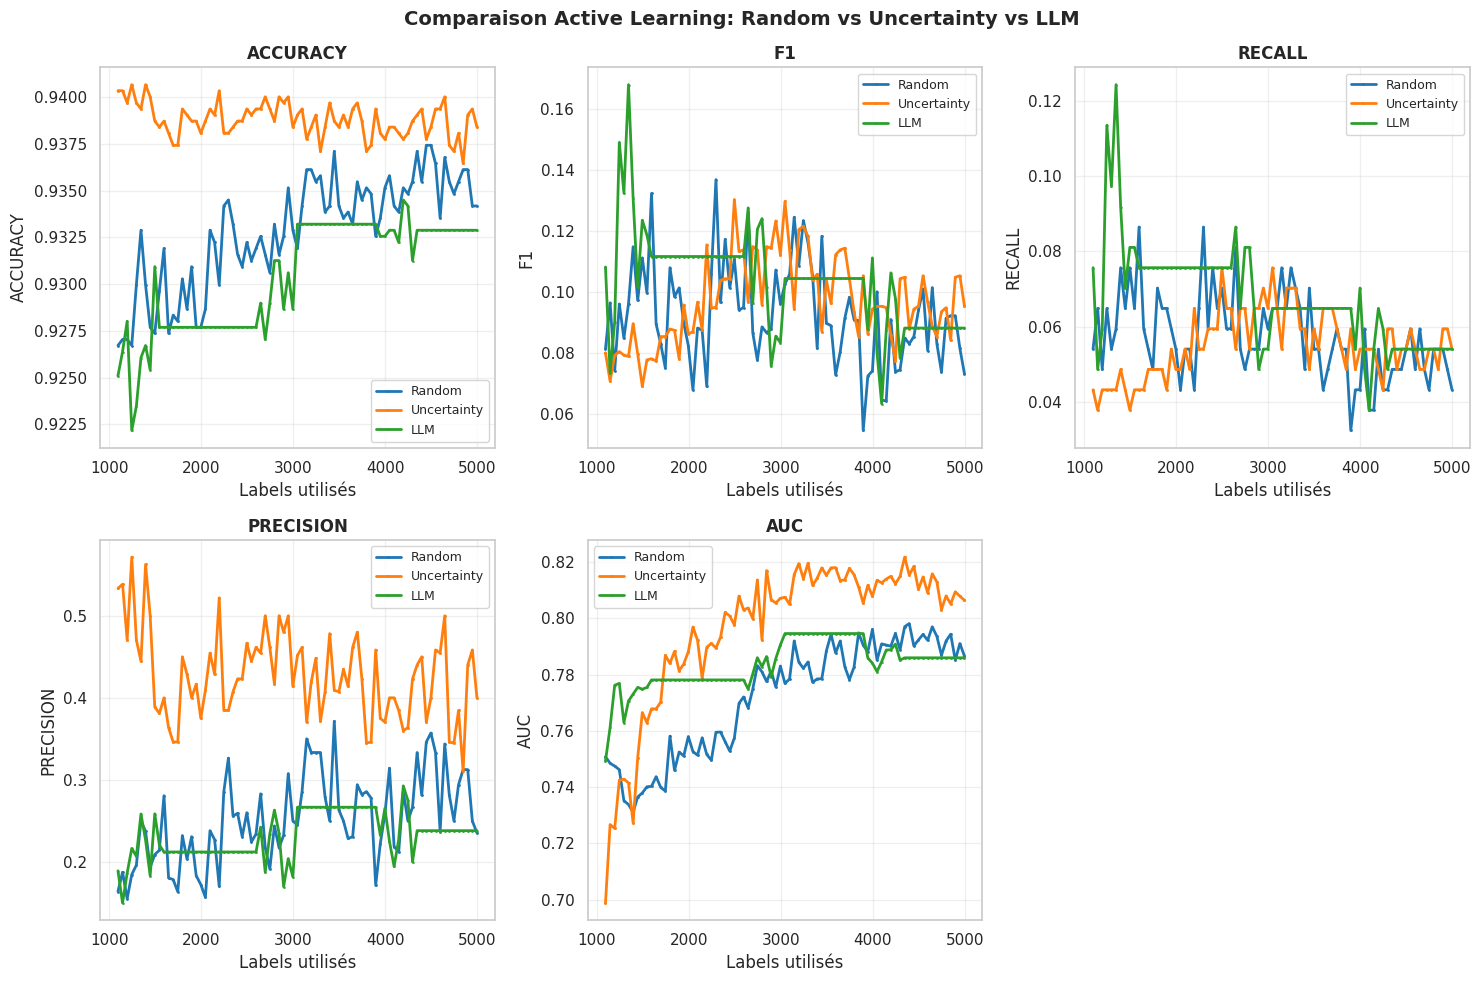

In [24]:
# ===========================
# VISUALISATION
# ===========================
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.0)
metrics = ["accuracy", "f1", "recall", "precision", "auc"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    ax.plot(results_df["labels_used"], results_df[f"{metric}_random_sampling"], 
            'o-', label="Random", color=colors[0], linewidth=2, markersize=1)
    
    ax.plot(results_df["labels_used"], results_df[f"{metric}_uncertainty_sampling"], 
            's-', label="Uncertainty", color=colors[1], linewidth=2, markersize=1)
    
    ax.plot(results_df["labels_used"], results_df[f"{metric}_llm_sampling"], 
            '^-', label="LLM", color=colors[2], linewidth=2, markersize=1)
    
    ax.set_title(metric.upper(), fontsize=12, fontweight='bold')
    ax.set_xlabel("Labels utilisés")
    ax.set_ylabel(metric.upper())
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

fig.delaxes(axes[5])

plt.suptitle("Comparaison Active Learning: Random vs Uncertainty vs LLM", 
             fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig('active_learning_results.png', dpi=150, bbox_inches='tight')
print("✓ Graphique sauvegardé: active_learning_results.png")
plt.show()